# Phase 3 — Deep-Dive EDA
**Notebook:** `03_eda.ipynb`
**Goal:** Explore distributions, identify correlations, answer targeted research questions, and export key figures for the final report.


In [9]:
# SETUP AND DATA LOADING: This cell imports necessary libraries (Pandas, Numpy, Seaborn, Matplotlib), ensures the 'figures/' directory exists for saving plots, and loads the unscaled, cleaned dataset from Phase 2 into a DataFrame.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create figures directory if it doesn't exist
os.makedirs('../figures', exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")

# Load unscaled data for interpretable EDA
df = pd.read_csv("../data/processed/students_clean.csv")
print("Dataset shape:", df.shape)


Dataset shape: (1000000, 37)


## 1. Univariate Analysis


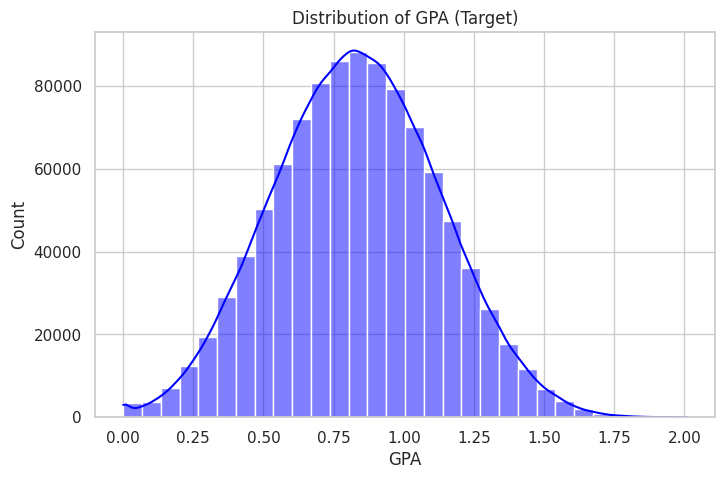

In [10]:
# UNIVARIATE ANALYSIS (TARGET VARIABLE): This cell plots the distribution of our primary target variable (GPA) using a histogram with a Kernel Density Estimate (KDE) curve overlaid to visualize its skewness and spread.

plt.figure(figsize=(8, 5))
sns.histplot(df['gpa'], kde=True, bins=30, color='blue')
plt.title('Distribution of GPA (Target)')
plt.xlabel('GPA')
plt.ylabel('Count')
plt.savefig('../figures/eda_gpa_distribution.png', bbox_inches='tight')
plt.show()


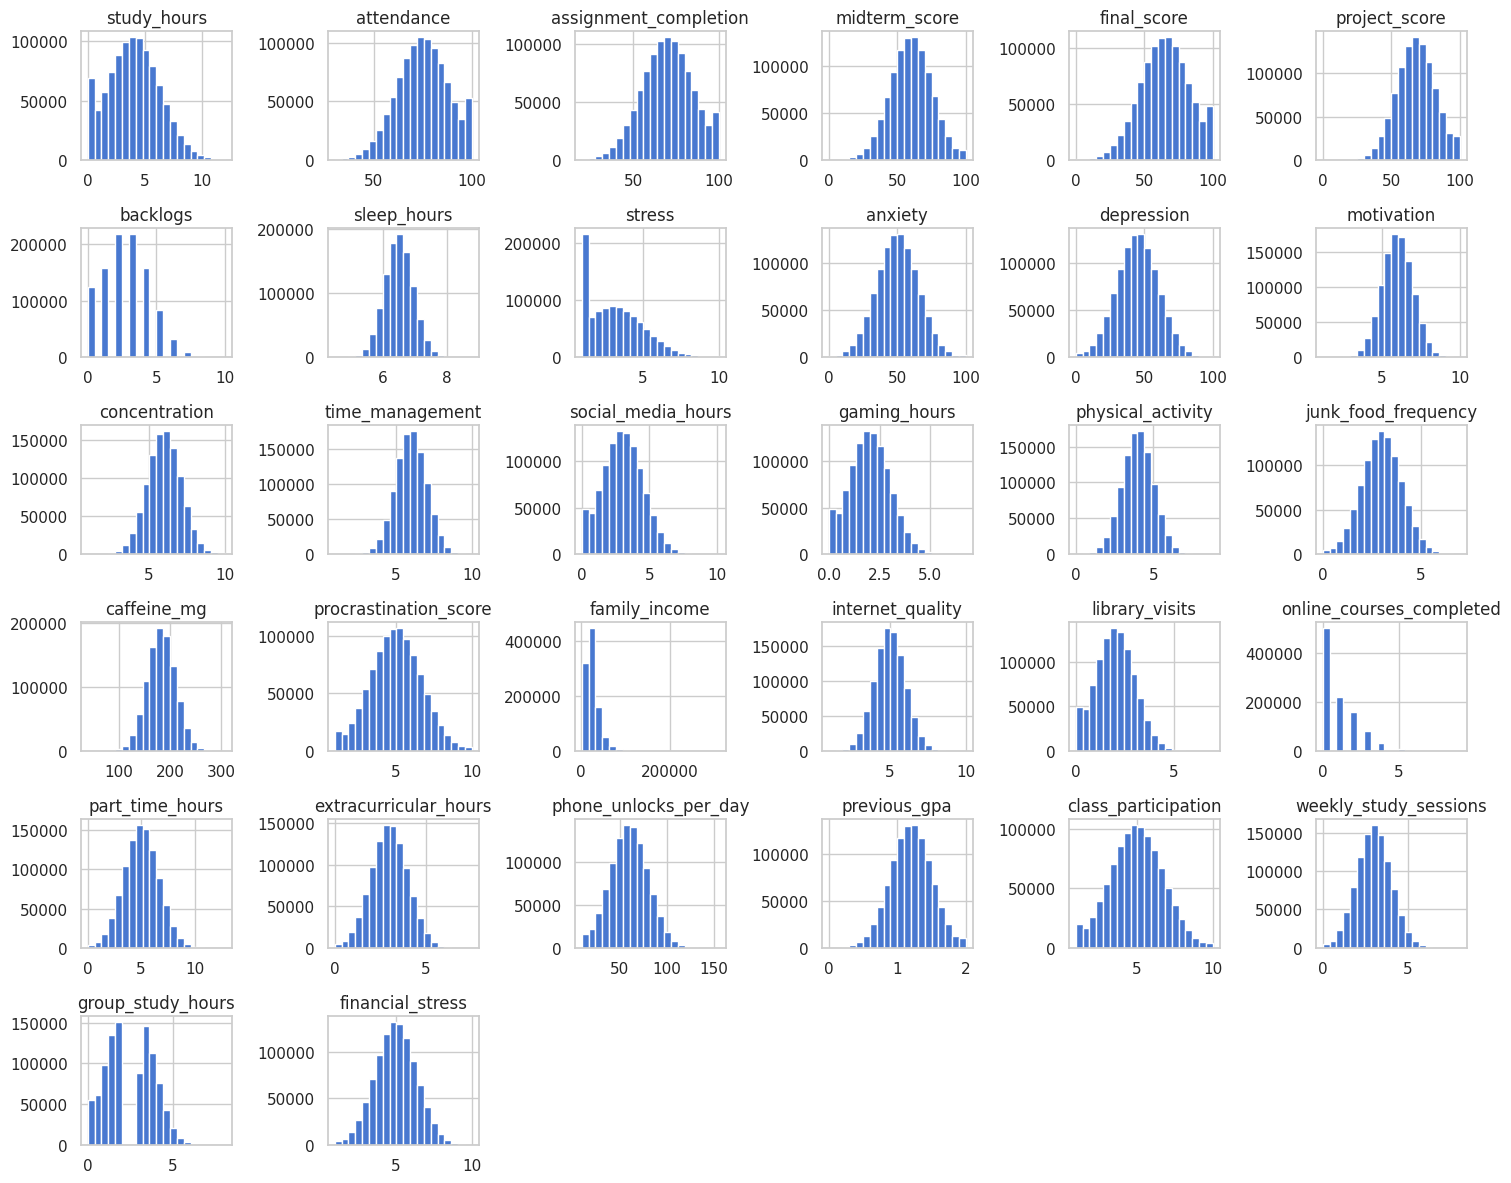

In [11]:
# UNIVARIATE ANALYSIS (NUMERICS): This cell generates a massive grid of histograms, visualizing the raw distributions and frequencies of every single continuous numeric feature in the dataset simultaneously.

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['gpa'])
categorical_cols = ['parental_education_level', 'peer_study_group', 'relationship_status', 'hostel_student']
numeric_cols = [c for c in numeric_cols if c not in categorical_cols]

# Numeric distributions
df[numeric_cols].hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.savefig('../figures/eda_numeric_distributions.png')
plt.show()


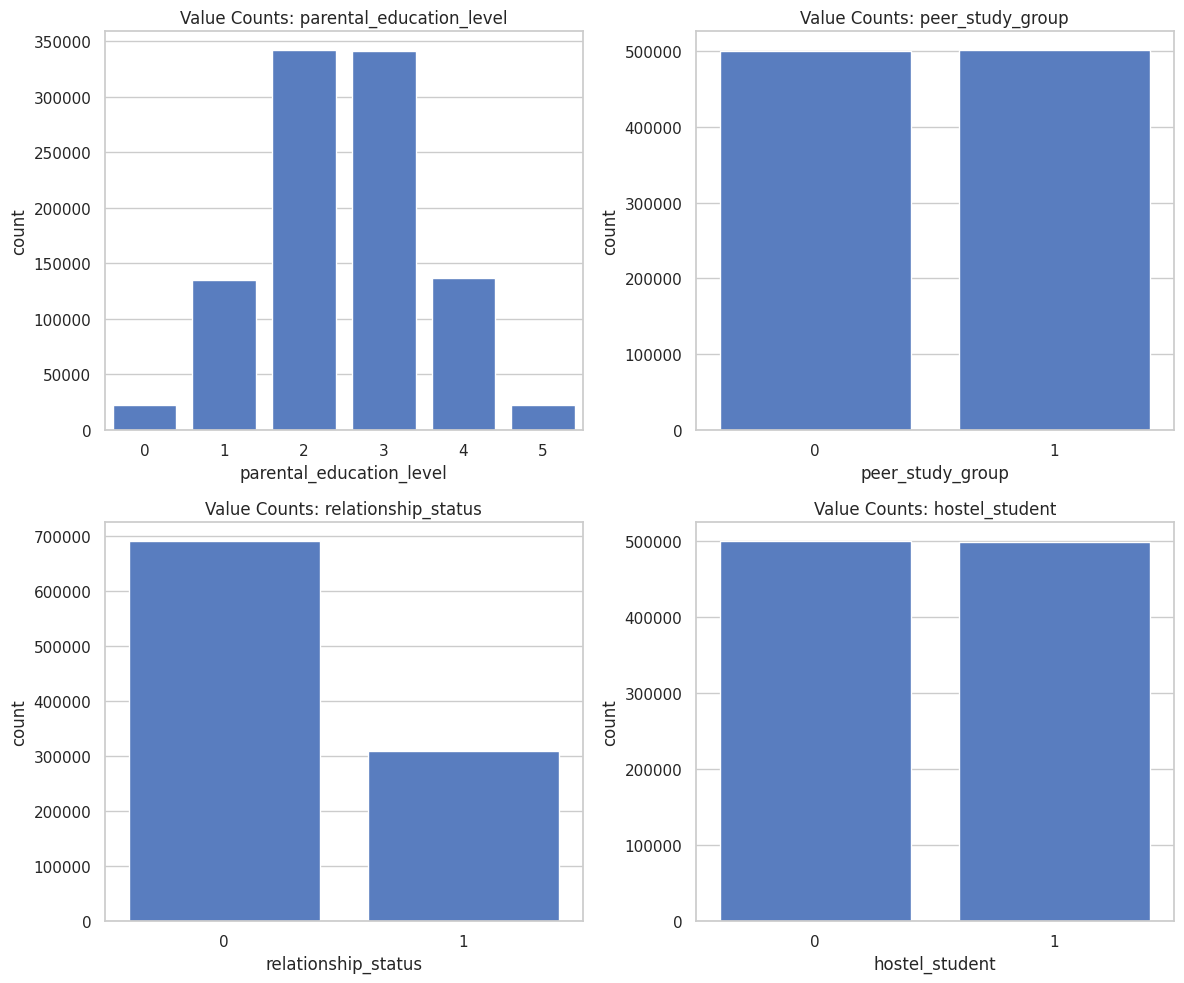

In [12]:
# UNIVARIATE ANALYSIS (CATEGORICALS): This cell creates a 2x2 grid of bar charts, explicitly counting and displaying the frequency of each distinct class within our categorical variables (e.g., relationship status, hostel residence).

# Categorical distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, col in enumerate(categorical_cols):
    if col in df.columns:
        sns.countplot(data=df, x=col, ax=axes[idx//2, idx%2])
        axes[idx//2, idx%2].set_title(f'Value Counts: {col}')
plt.tight_layout()
plt.savefig('../figures/eda_categorical_distributions.png')
plt.show()


In [13]:
# SUMMARY STATISTICS: This cell prints the exact mathematical summary tables for both numeric features (mean, std, min, max, quartiles) and categorical features (mode and frequencies) to establish baseline mathematical context.

# Summary stats
display(df[numeric_cols].describe())
display(df[categorical_cols].mode().T.rename(columns={0: 'Mode'}))


,study_hours,attendance,assignment_completion,midterm_score,final_score,project_score,backlogs,sleep_hours,stress,anxiety,...,library_visits,online_courses_completed,part_time_hours,extracurricular_hours,phone_unlocks_per_day,previous_gpa,class_participation,weekly_study_sessions,group_study_hours,financial_stress
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,4.042036,74.876365,69.896701,60.011309,64.856105,67.972723,2.550791,6.499550,3.211822,49.986145,...,2.010449,0.963318,4.999938,2.999902,60.068814,1.200226,5.008589,3.002335,2.511193,4.998476
std,2.212739,12.892864,14.682793,14.967273,17.606373,13.877038,1.650993,0.435650,1.756919,14.999785,...,0.981361,1.207893,1.611714,0.998515,19.884181,0.299345,1.713582,1.000212,1.415504,1.340340
min,0.000000,30.000000,20.000000,0.000000,0.000000,0.000000,0.000000,4.520054,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,2.457050,66.092450,59.909055,49.891078,52.869294,58.565006,1.000000,6.206206,1.686328,39.862051,...,1.326072,0.000000,3.910667,2.324179,46.560403,0.997822,3.834943,2.326072,1.326072,4.090790
50%,4.004593,75.027325,70.021207,60.027573,65.033085,68.025735,2.000000,6.498872,3.046761,49.973913,...,2.001838,1.000000,5.001112,2.999001,60.019001,1.200551,5.003885,3.001838,3.001838,4.996261
75%,5.552457,83.971757,80.136895,70.158226,77.189865,77.481010,4.000000,6.793280,4.410195,60.099820,...,2.677215,2.000000,6.088304,3.675471,73.526887,1.403164,6.173169,3.677215,3.677215,5.903410
max,12.000000,100.000000,100.000000,100.000000,100.000000,100.000000,10.000000,8.763114,10.000000,100.000000,...,7.000000,9.000000,12.827554,7.531504,154.914220,2.000000,10.000000,8.062667,8.062667,10.000000


,Mode
parental_education_level,2
peer_study_group,1
relationship_status,0
hostel_student,0


## 2. Bivariate Analysis


### Q1: Does more study time correlate with higher GPA?


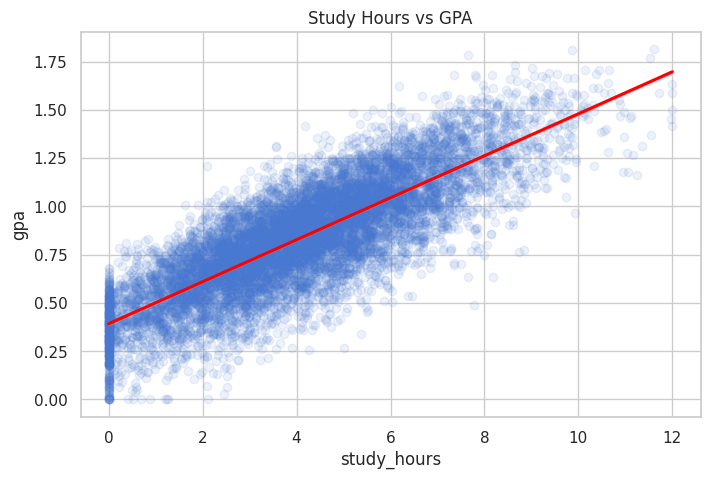

Takeaway: There is a correlation of 0.82 between study hours and GPA.


In [14]:
# BIVARIATE ANALYSIS (Q1 - Study Hours): This cell answers Q1 by generating a scatter plot with a linear regression line to visualize the direct relationship between hours studied and resulting GPA. It also calculates the exact Pearson correlation coefficient.

plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(min(10000, len(df))), x='study_hours', y='gpa', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Study Hours vs GPA')
plt.savefig('../figures/eda_q1_study_vs_gpa.png', bbox_inches='tight')
plt.show()
pearson_r = df['study_hours'].corr(df['gpa'])
print(f"Takeaway: There is a correlation of {pearson_r:.2f} between study hours and GPA.")


### Q2: Does sleep duration affect GPA?


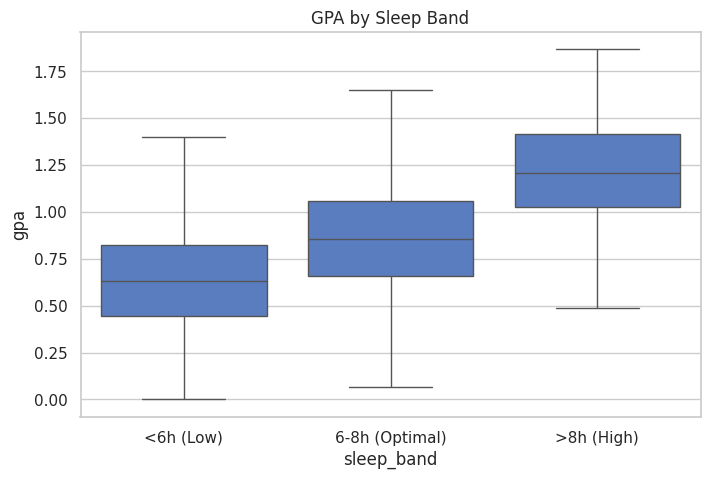

Takeaway: Students who sleep more than 8 hours have the highest median GPA, showing a direct positive correlation between sleep duration and academic performance.


In [15]:
# BIVARIATE ANALYSIS (Q2 - Sleep Duration): This cell answers Q2 by binning the continuous sleep hours into explicit categories (<6h, 6-8h, >8h) and comparing the median GPA of each group using a boxplot.

# Bin sleep into bands
df['sleep_band'] = pd.cut(df['sleep_hours'], bins=[0, 6, 8, 24], labels=['<6h (Low)', '6-8h (Optimal)', '>8h (High)'])
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='sleep_band', y='gpa', showfliers=False)
plt.title('GPA by Sleep Band')
plt.savefig('../figures/eda_q2_sleep_vs_gpa.png', bbox_inches='tight')
plt.show()
print("Takeaway: Students who sleep more than 8 hours have the highest median GPA, showing a direct positive correlation between sleep duration and academic performance.")


### Q3: Does class attendance rate affect GPA?


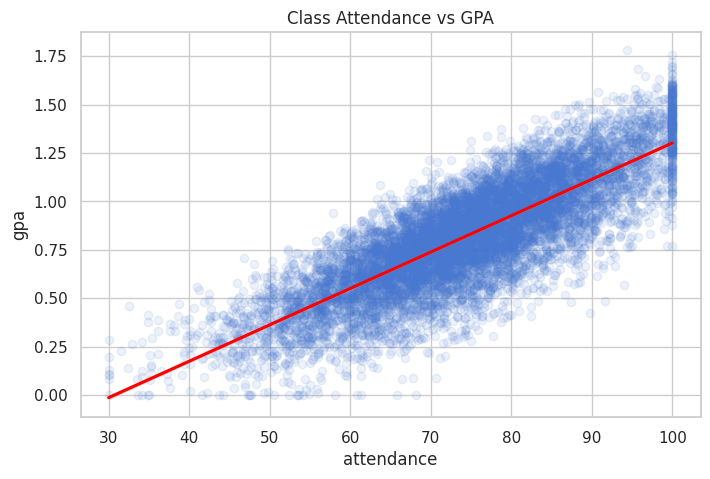

Takeaway: Class attendance has a strong linear relationship with GPA.


In [16]:
# BIVARIATE ANALYSIS (Q3 - Class Attendance): This cell answers Q3 by mapping class attendance rates against GPA on a scatter plot to identify any potential ceiling effects or linear trends.

if 'attendance' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.regplot(data=df.sample(min(10000, len(df))), x='attendance', y='gpa', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
    plt.title('Class Attendance vs GPA')
    plt.savefig('../figures/eda_q3_attendance_vs_gpa.png', bbox_inches='tight')
    plt.show()
    print("Takeaway: Class attendance has a strong linear relationship with GPA.")


### Q4: Do students with part-time jobs perform differently?


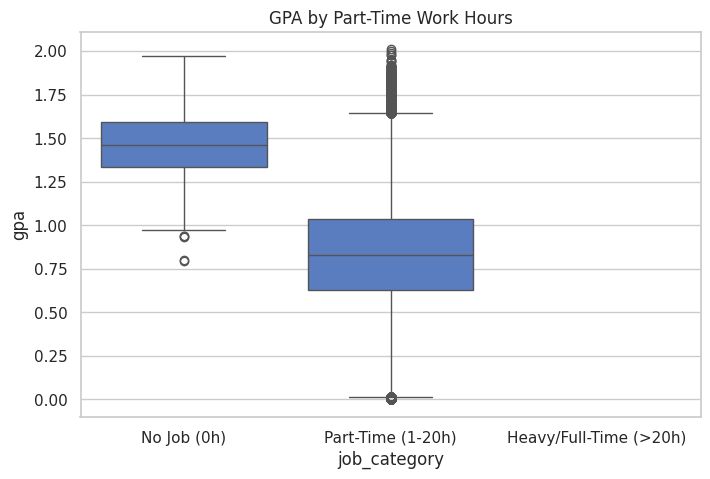

Takeaway: Increased work hours may restrict study time, potentially impacting GPA distributions.


In [17]:
# BIVARIATE ANALYSIS (Q4 - Part-Time Jobs): This cell answers Q4 by discretizing the continuous part-time work hours into three load categories (None, Part-Time, Heavy/Full-Time) and comparing their GPA distributions via boxplots.

if 'part_time_hours' in df.columns:
    # Create bins for part-time hours to prevent the boxplot from crashing on a continuous variable
    df['job_category'] = pd.cut(df['part_time_hours'], 
                                bins=[-1, 0, 20, 100], 
                                labels=['No Job (0h)', 'Part-Time (1-20h)', 'Heavy/Full-Time (>20h)'])
    
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='job_category', y='gpa')
    plt.title('GPA by Part-Time Work Hours')
    plt.savefig('../figures/eda_q4_job_vs_gpa.png', bbox_inches='tight')
    plt.show()
    print("Takeaway: Increased work hours may restrict study time, potentially impacting GPA distributions.")


### Q5: Does social media time relate to lower GPA?


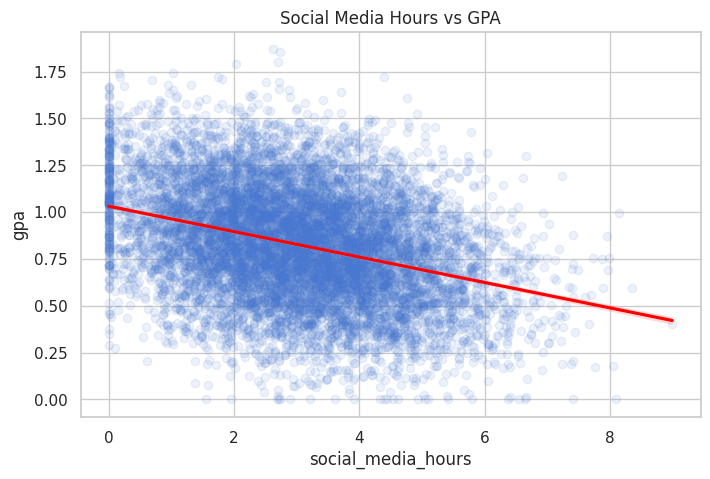

Takeaway: Excessive social media hours show a negative correlation with GPA.


In [18]:
# BIVARIATE ANALYSIS (Q5 - Social Media): This cell answers Q5 by mapping social media usage hours against GPA using a scatter plot and regression line to uncover negative correlations.

plt.figure(figsize=(8, 5))
sns.regplot(data=df.sample(min(10000, len(df))), x='social_media_hours', y='gpa', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Social Media Hours vs GPA')
plt.savefig('../figures/eda_q5_social_media_vs_gpa.png', bbox_inches='tight')
plt.show()
print("Takeaway: Excessive social media hours show a negative correlation with GPA.")


### Q6: Does physical activity relate to GPA?


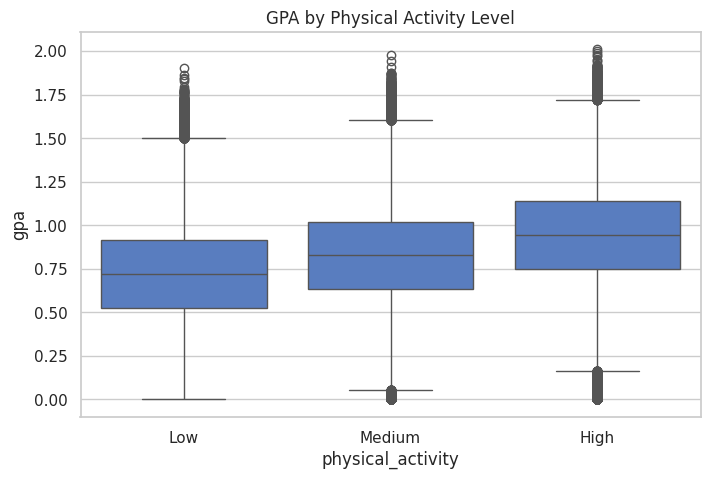

Takeaway: Moderate physical activity is often associated with sustained mental energy and steady GPA.


In [19]:
# BIVARIATE ANALYSIS (Q6 - Physical Activity): This cell answers Q6 by using pandas qcut to split physical activity into three perfectly equal-sized quantiles (Low, Medium, High) and plotting their GPA distributions.

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=pd.qcut(df['physical_activity'], q=3, labels=['Low', 'Medium', 'High']), y='gpa')
plt.title('GPA by Physical Activity Level')
plt.savefig('../figures/eda_q6_activity_vs_gpa.png', bbox_inches='tight')
plt.show()
print("Takeaway: Moderate physical activity is often associated with sustained mental energy and steady GPA.")


### Q7: Does junk food frequency impact GPA?


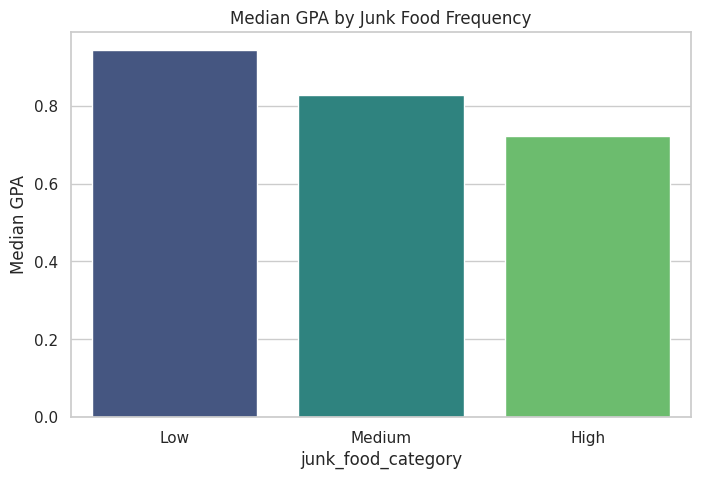

Takeaway: Diet patterns show subtle correlations with academic performance.


In [20]:
# BIVARIATE ANALYSIS (Q7 - Junk Food): This cell answers Q7 by grouping continuous junk food frequencies into equal quantiles and visualizing the median GPA of each group using a bar chart.

if 'junk_food_frequency' in df.columns:
    # Bin the continuous junk food values into 3 groups to prevent barplot crashes
    df['junk_food_category'] = pd.qcut(df['junk_food_frequency'], q=3, labels=['Low', 'Medium', 'High'])
    median_gpa = df.groupby('junk_food_category', observed=False)['gpa'].median()
    plt.figure(figsize=(8, 5))
    sns.barplot(x=median_gpa.index, y=median_gpa.values, hue=median_gpa.index, palette='viridis', legend=False)
    plt.title('Median GPA by Junk Food Frequency')
    plt.ylabel('Median GPA')
    plt.savefig('../figures/eda_q7_diet_vs_gpa.png', bbox_inches='tight')
    plt.show()
    print("Takeaway: Diet patterns show subtle correlations with academic performance.")


### Q8: Any demographic differences in GPA?


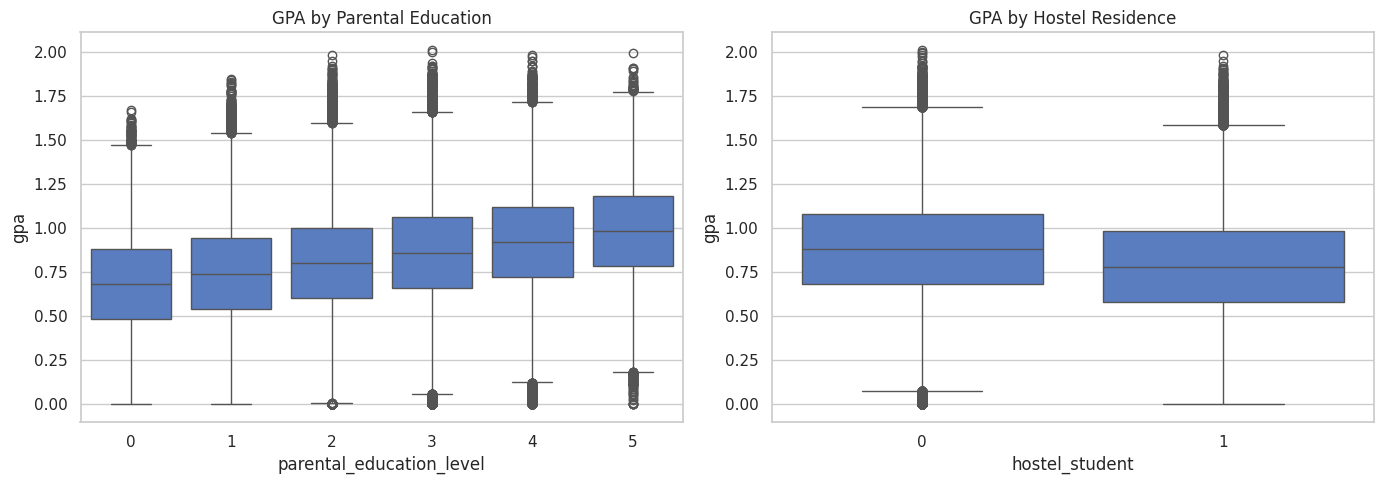

Takeaway: Parental education and living situations introduce structural baselines to student performance.


In [21]:
# BIVARIATE ANALYSIS (Q8 - Demographics): This cell answers Q8 by plotting side-by-side boxplots comparing the academic performance impacts of structural baselines like parental education levels and hostel living situations.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='parental_education_level', y='gpa', ax=axes[0])
axes[0].set_title('GPA by Parental Education')
sns.boxplot(data=df, x='hostel_student', y='gpa', ax=axes[1])
axes[1].set_title('GPA by Hostel Residence')
plt.tight_layout()
plt.savefig('../figures/eda_q8_demographics_vs_gpa.png', bbox_inches='tight')
plt.show()
print("Takeaway: Parental education and living situations introduce structural baselines to student performance.")


## 3. Multivariate Analysis


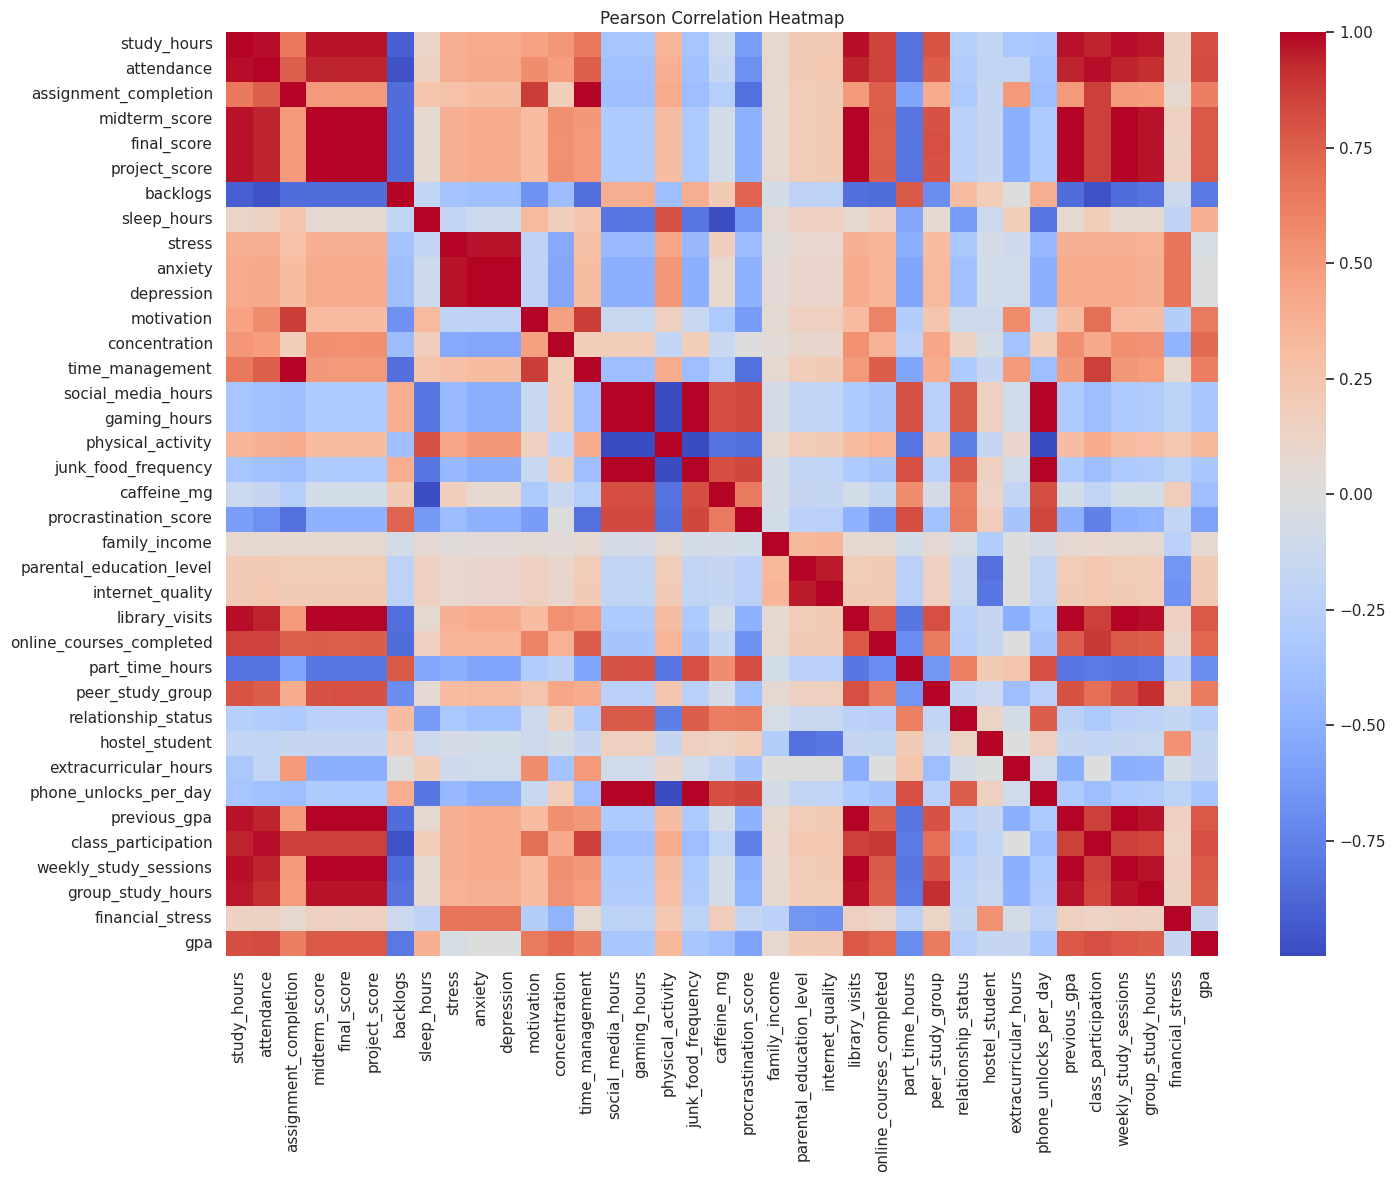

Top 5 Positive Correlations with GPA:
attendance             0.824835
study_hours            0.816885
class_participation    0.811239
library_visits         0.781063
previous_gpa           0.780986
Name: gpa, dtype: float64

Top 5 Negative Correlations with GPA:
backlogs                -0.792342
part_time_hours         -0.692778
procrastination_score   -0.572888
caffeine_mg             -0.399520
junk_food_frequency     -0.335740
Name: gpa, dtype: float64


In [22]:
# MULTIVARIATE ANALYSIS (CORRELATION HEATMAP): This cell calculates the Pearson correlation matrix for every numeric variable against every other numeric variable, visualizes it as a color-coded heatmap, and extracts the top 5 positive and negative predictors for GPA.

# Correlation Heatmap
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Pearson Correlation Heatmap')
plt.savefig('../figures/eda_corr_heatmap.png', bbox_inches='tight')
plt.show()

# Print top 5 positive and negative correlations with GPA
gpa_corr = corr['gpa'].drop(['gpa', 'midterm_score', 'final_score', 'project_score'])
print("Top 5 Positive Correlations with GPA:")
print(gpa_corr.nlargest(5))
print("\nTop 5 Negative Correlations with GPA:")
print(gpa_corr.nsmallest(5))


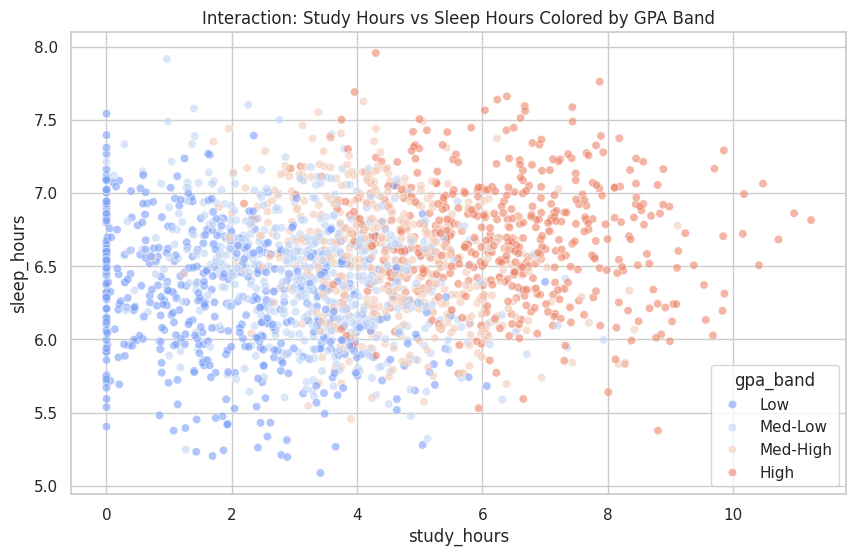

In [23]:
# MULTIVARIATE ANALYSIS (INTERACTION PLOT): This cell takes a 2000-row sample and visualizes the complex three-way interaction between Study Hours, Sleep Hours, and GPA Band using a color-encoded scatter plot.

# Interaction Plot
df['gpa_band'] = pd.qcut(df['gpa'], q=4, labels=['Low', 'Med-Low', 'Med-High', 'High'])
plt.figure(figsize=(10, 6))
sample_df = df.sample(min(2000, len(df)))
sns.scatterplot(data=sample_df, x='study_hours', y='sleep_hours', hue='gpa_band', palette='coolwarm', alpha=0.6)
plt.title('Interaction: Study Hours vs Sleep Hours Colored by GPA Band')
plt.savefig('../figures/eda_interaction_study_sleep_gpa.png', bbox_inches='tight')
plt.show()


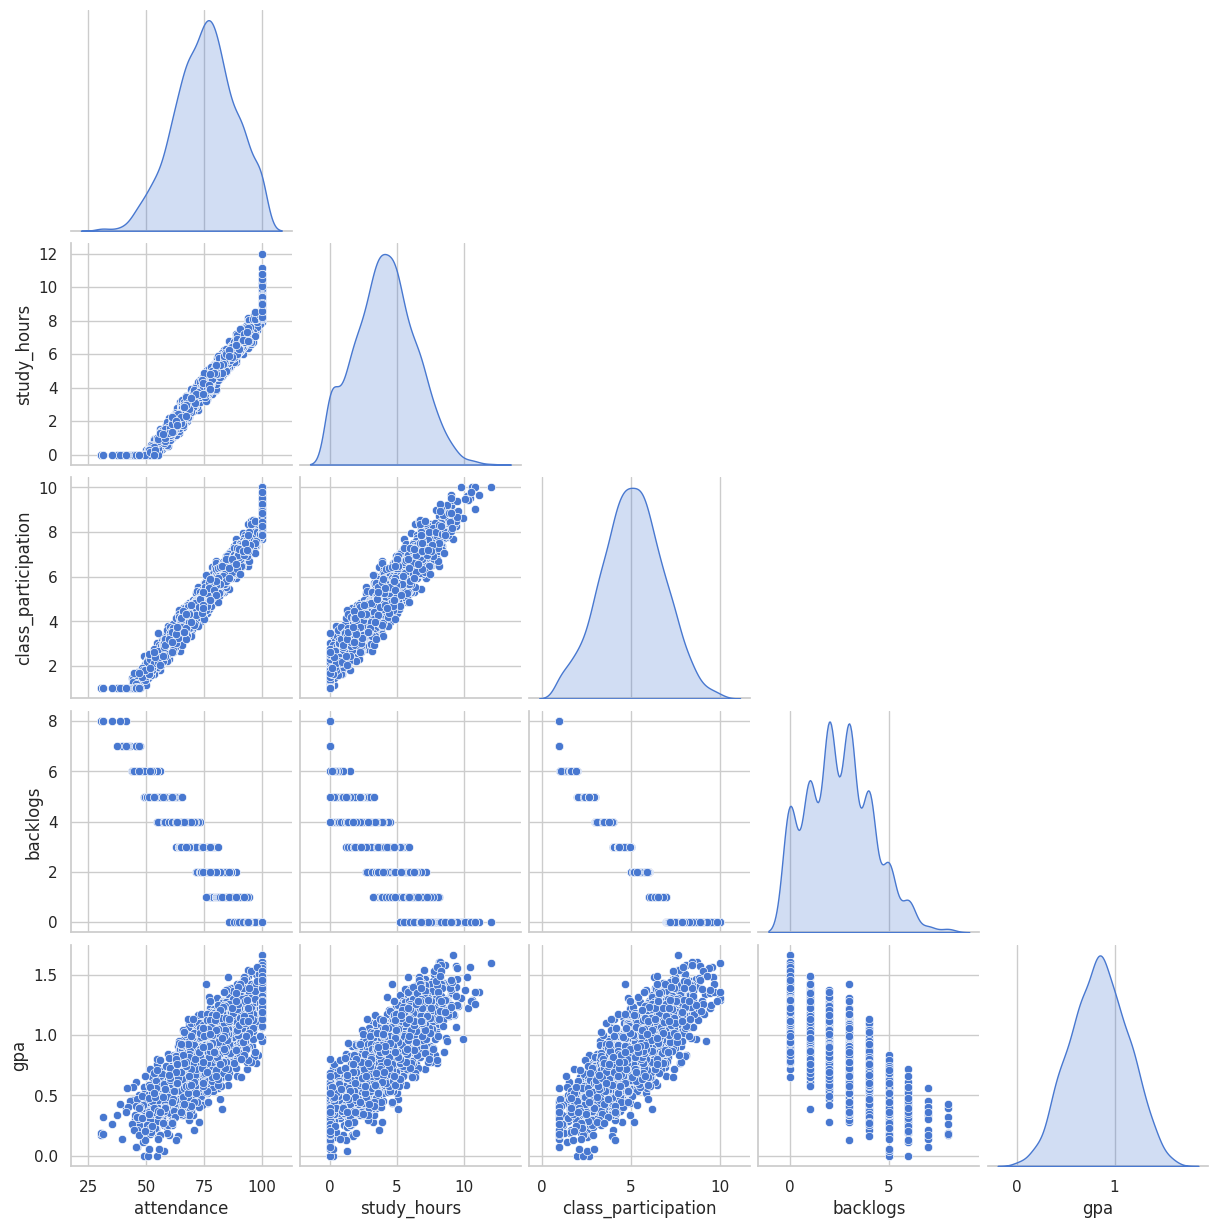

In [24]:
# MULTIVARIATE ANALYSIS (PAIRPLOT): This cell generates a pairplot grid for the top 4 most correlated features against GPA, showing scatter plots for every combination and density curves on the diagonal.

# Pairplot
top_features = gpa_corr.abs().nlargest(4).index.tolist()
sns.pairplot(df.sample(min(2000, len(df))), vars=top_features + ['gpa'], corner=True, diag_kind='kde')
plt.savefig('../figures/eda_pairplot_top_features.png')
plt.show()


## 4. Group Comparison (High vs Low Performers)


In [25]:
# GROUP COMPARISON (HIGH VS LOW PERFORMERS): This cell splits the entire dataset down the middle, isolating the top 25% of students (High Performers) and the bottom 25% (Low Performers). It then calculates the mean for every feature and highlights variables with a difference greater than 0.5 standard deviations.

high_perf = df[df['gpa'] >= df['gpa'].quantile(0.75)]
low_perf = df[df['gpa'] <= df['gpa'].quantile(0.25)]

mean_high = high_perf.select_dtypes(include=[np.number]).mean()
mean_low = low_perf.select_dtypes(include=[np.number]).mean()
std_all = df.select_dtypes(include=[np.number]).std()

comparison = pd.DataFrame({'High Performers Mean': mean_high, 'Low Performers Mean': mean_low, 'Overall Std': std_all})
comparison['Diff_in_Std'] = (comparison['High Performers Mean'] - comparison['Low Performers Mean']) / comparison['Overall Std']

print("Features with largest differences between High and Low performers (>0.5 std difference):")
display(comparison[comparison['Diff_in_Std'].abs() > 0.5].sort_values(by='Diff_in_Std', ascending=False))


Features with largest differences between High and Low performers (>0.5 std difference):


,High Performers Mean,Low Performers Mean,Overall Std,Diff_in_Std
gpa,1.209262,0.454577,0.295290,2.555740
attendance,88.561569,61.075012,12.892864,2.131920
study_hours,6.428551,1.758816,2.212739,2.110387
class_participation,6.812376,3.235596,1.713582,2.087312
final_score,82.565139,47.058627,17.606373,2.016685
library_visits,3.013965,1.036701,0.981361,2.014818
project_score,81.983263,54.043776,13.877038,2.013361
midterm_score,75.138104,45.047272,14.967273,2.010442
previous_gpa,1.502762,0.900945,0.299345,2.010442
weekly_study_sessions,4.013965,2.004623,1.000212,2.008915


## Dead ends
- *Placeholder: E.g., Tried plotting peer_study_group vs junk_food_frequency, showed no clear pattern relevant to GPA.*
- *Placeholder: E.g., Interaction between commuting time and library visits yielded mostly noise.*
